- Ga naar https://insight.quantified.eu/api/auth/login/?next=/api/doc
- Log in als JSpan@ilionx.com
- Authorize als JSpan@ilionx.com
- Ga naar Token --> POST /token/login --> Try it out --> Execute
- Copy-paste Token in authorization_key variabele achter "Bearer "

In [10]:
# import json

# # Assuming you have the JSON data stored in a file called 'data.json'
# with open('default_parameters.json') as file:
#     data = json.load(file)

# # Dynamically create variables based on the JSON keys
# print('The default variables are:')
# for key, value in data.items():
#     globals()[key] = value
#     print(key)

from default_parameters import get_parameters

token, device_name_ids = get_parameters()

In [8]:
import requests
import pandas as pd
import matplotlib as plt

authorization_key = f"Bearer {token}"

In [3]:
# url = r"https://insight.quantified.eu/api/soil_temperature_events/"
# url = r"https://insight.quantified.eu/api/battery_voltage_events/"

df_final_permittivity = pd.DataFrame()
df_final_battery = pd.DataFrame()
resp = 200

url_list = [r"https://insight.quantified.eu/api/soil_relative_permittivity_events/", 
            r"https://insight.quantified.eu/api/battery_voltage_events/"]

for url_path in url_list:
    for device_ID in device_name_ids.values():
        url = url_path
        while url != None:

            headers = {
                "accept": "application/json",
                "authorization": authorization_key,
            }

            params = {
                "device_id": device_ID,
                "limit": 100,
            }

            response = requests.get(url, headers=headers, params=params)
            resp = response.status_code

            if resp == 200:
                df = pd.read_json(response.text)

                if url_path == url_list[0]:
                    df_final_permittivity = pd.concat([df_final_permittivity,df])
                elif url_path == url_list[1]:
                    df_final_battery = pd.concat([df_final_battery,df])

                txt_json = response.json()
                url = txt_json['next']

# df_final.to_excel('20230516 - all_sensor_data_raw.xlsx')

df_final_permittivity

,next,previous,results
0,https://insight.quantified.eu/api/soil_relativ...,NaN,"{'timestamp': 1680043662, 'gateway_receive_tim..."
1,https://insight.quantified.eu/api/soil_relativ...,NaN,"{'timestamp': 1679278139, 'gateway_receive_tim..."
2,https://insight.quantified.eu/api/soil_relativ...,NaN,"{'timestamp': 1678512935, 'gateway_receive_tim..."
3,https://insight.quantified.eu/api/soil_relativ...,NaN,"{'timestamp': 1678034676, 'gateway_receive_tim..."
4,https://insight.quantified.eu/api/soil_relativ...,NaN,"{'timestamp': 1677315251, 'gateway_receive_tim..."
...,...,...,...
0,NaN,https://insight.quantified.eu/api/soil_relativ...,"{'timestamp': 1649461050, 'gateway_receive_tim..."
1,NaN,https://insight.quantified.eu/api/soil_relativ...,"{'timestamp': 1649452846, 'gateway_receive_tim..."
2,NaN,https://insight.quantified.eu/api/soil_relativ...,"{'timestamp': 1649440798, 'gateway_receive_tim..."
3,NaN,https://insight.quantified.eu/api/soil_relativ...,"{'timestamp': 1649432594, 'gateway_receive_tim..."


In [4]:
import pytz

def quantified_to_dataframe(df):
        df_results = pd.json_normalize(df['results'])
        df_results['gateway_receive_time'] = pd.to_datetime(df_results['gateway_receive_time'], utc=True)
        local_tz = pytz.timezone('Europe/Amsterdam')  # replace with your local timezone
        df_results['gateway_receive_time'] = df_results['gateway_receive_time'].dt.tz_convert(local_tz)
        df_results['gateway_receive_time'] = df_results['gateway_receive_time'].dt.strftime('%Y-%m-%d %H:%M:%S')
        df_results['gateway_receive_time'] = pd.to_datetime(df_results['gateway_receive_time'])

        # split datetime column into separate date and time columns
        df_results['date'] = df_results['gateway_receive_time'].dt.date
        df_results['time'] = df_results['gateway_receive_time'].dt.time

        # extract separate columns for year, month, day, hour, minute, and second
        df_results['year'] = df_results['gateway_receive_time'].dt.year
        df_results['month'] = df_results['gateway_receive_time'].dt.month
        df_results['day'] = df_results['gateway_receive_time'].dt.day
        df_results['hour'] = df_results['gateway_receive_time'].dt.hour
        df_results['minute'] = df_results['gateway_receive_time'].dt.minute
        df_results['second'] = df_results['gateway_receive_time'].dt.second

        return df_results

df_results_permittivity = quantified_to_dataframe(df_final_permittivity)
df_results_battery = quantified_to_dataframe(df_final_battery)

In [6]:
df_results_permittivity.to_excel('20230619 - Permittivity_data.xlsx',index=False)
df_results_battery.to_excel('20230619 - Battery_data.xlsx',index=False)

In [107]:
test = df_results.sort_values(by='gateway_receive_time').copy()
test['time_diff_hours'] = test['gateway_receive_time'].diff().dt.total_seconds() / 3600
test

,timestamp,gateway_receive_time,device,value,date,time,year,month,day,hour,minute,second,time_diff_hours
99,1681384962,2023-04-13 13:22:42,415,0.88,2023-04-13,13:22:42,2023,4,13,13,22,42,NaN
98,1681399188,2023-04-13 17:19:48,415,0.88,2023-04-13,17:19:48,2023,4,13,17,19,48,3.951667
97,1681427645,2023-04-14 01:14:05,415,0.88,2023-04-14,01:14:05,2023,4,14,1,14,5,7.904722
96,1681441871,2023-04-14 05:11:11,415,0.88,2023-04-14,05:11:11,2023,4,14,5,11,11,3.951667
95,1681456098,2023-04-14 09:08:18,415,0.92,2023-04-14,09:08:18,2023,4,14,9,8,18,3.951944
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,1683477491,2023-05-07 18:38:11,415,15.01,2023-05-07,18:38:11,2023,5,7,18,38,11,3.943333
3,1683505866,2023-05-08 02:31:06,415,14.88,2023-05-08,02:31:06,2023,5,8,2,31,6,7.881944
2,1683520041,2023-05-08 06:27:21,415,14.88,2023-05-08,06:27:21,2023,5,8,6,27,21,3.937500
1,1683534215,2023-05-08 10:23:35,415,14.76,2023-05-08,10:23:35,2023,5,8,10,23,35,3.937222


<Axes: xlabel='gateway_receive_time'>

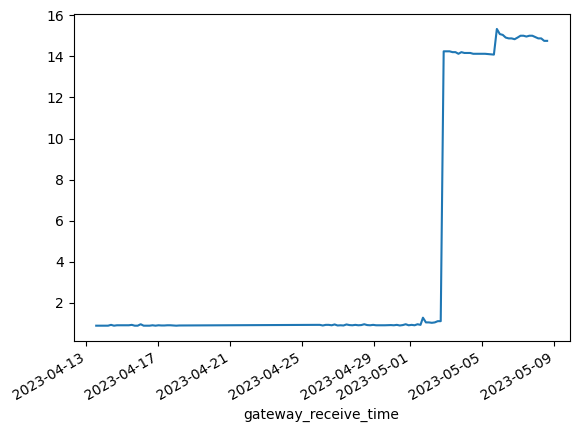

In [102]:
df_value = df_results.set_index('gateway_receive_time')
df_value['value'].plot()